# ***Sesgo y Fairness***

Para esta problemática se analiza el **sesgo y la equidad** (*fairness*) en las variables sensibles de raza (`race`), género (`gender`) y edad (`age`). A diferencia de las variables clínicas, los atributos sociodemográficos no deberían determinar por sí mismos el resultado de la atención médica. El objetivo es identificar sesgos injustos o históricos que el modelo pueda heredar y amplificar, asegurando que el sistema sea equitativo y no discrimine a grupos vulnerables.

La clase 2 es la más crítica: un paciente de alto riesgo no detectado puede sufrir complicaciones graves sin intervención preventiva. Por ello, el análisis de fairness se centra en las tasas de error del modelo sobre esta clase, desagregadas por grupo sensible.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report,  recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from fairlearn.metrics import MetricFrame

In [22]:
SEED = 42
np.random.seed(SEED)

Para analizar si nuestro modelo es justo y no discrimina, necesitamos entender perfectamente qué grupos de personas estamos estudiando. Sin embargo, al preparar los datos para los distintos modelos, la información original suele transformarse en números complejos que hacen que los gráficos finales sean difíciles de leer. Por ello, añadimos un paso intermedio para recuperar las etiquetas originales de cada grupo.

Al principio, eliminamos los códigos de identificación de los pacientes (`encounter_id` y `patient_nbr`) porque no aportan nada para predecir las readmisiones y para proteger la privacidad de las personas. Después, para que el modelo pudiera trabajar, convertimos las características personales en números: sobre la raza (`race`) se realizó una codificación por frecuencia, el género (`gender`) se guardó como 0 o 1, y la edad (`age`) se dividió en números del 0 al 9 para representar las distintas etapas de la vida.

Aunque estos cambios hacen que el modelo funcione mejor y más rápido, trabajar directamente con números abstractos en los gráficos dificulta ver si estamos cometiendo injusticias. Es muy fácil confundirse si en un gráfico de equidad solo vemos números en lugar de saber si estamos hablando de hombres, mujeres, jóvenes o ancianos.

Para solucionar este problema, creamos una función llamada `aplicar_etiquetas()`. Este código traduce automáticamente esos números de vuelta a sus nombres reales (como "Caucasian", "Female" o el rango de edad "[70-80)"). En el caso de la raza, como los números podían tener pequeños desajustes de decimales al guardar el archivo, el código busca inteligentemente el nombre que mejor se adapta a cada número.

Gracias a esto, tanto los datos de los pacientes como la variable que queremos predecir quedan listos para usarse en herramientas visuales y de equidad (como `Fairlearn`). Así nos aseguramos de que cualquier análisis posterior sea totalmente transparente, claro y refleje la realidad de las personas estudiadas.

In [23]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=',', quotechar='"')

# Eliminar identificadores
cols_to_drop = ['encounter_id', 'patient_nbr']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Distribución de la variable objetivo:")
vc = df['readmitted'].value_counts().sort_index()
for cls, n in vc.items():
    etiqueta = {0: 'No readmitido', 1: 'Readmitido >30d', 2: 'Readmitido <30d'}[cls]
    print(f"  Clase {cls} ({etiqueta}): {n:,}  ({n/len(df)*100:.1f}%)")

y = df['readmitted']
X = df.drop(columns=['readmitted'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# ── Mapas de etiquetas para visualización ──
# race: frequency encoding -> etiqueta original
_race_freq_map = {
    0.7656981428411166: 'Caucasian',
    0.1925591261868581: 'AfricanAmerican',
    0.0202339551059121: 'Hispanic',
    0.0151346720651076: 'Other',
    0.0063741038010056: 'Asian',
}
# Construcción robusta: buscar la freq más cercana en el df
def _map_race(val):
    return min(_race_freq_map, key=lambda k: abs(k - val))

_race_labels = {v: _race_freq_map[_map_race(v)] for v in df['race'].unique()}

# gender: 1 = Female, 0 = Male
_gender_labels = {1: 'Female', 0: 'Male', 2: 'Unknown'}

# age: ordinal 0-9
_age_labels = {
    0: '[0-10)',  1: '[10-20)', 2: '[20-30)', 3: '[30-40)',
    4: '[40-50)', 5: '[50-60)', 6: '[60-70)', 7: '[70-80)',
    8: '[80-90)', 9: '[90-100)'
}

LABEL_MAPS = {'race': _race_labels, 'gender': _gender_labels, 'age': _age_labels}

def aplicar_etiquetas(df_in, cols=None):
    """Devuelve una copia de df_in con las columnas sensibles traducidas a etiquetas legibles."""
    df_out = df_in.copy()
    if cols is None:
        cols = list(LABEL_MAPS.keys())
    for col in cols:
        if col in df_out.columns and col in LABEL_MAPS:
            df_out[col] = df_out[col].map(LABEL_MAPS[col]).fillna(df_out[col].astype(str))
    return df_out


Distribución de la variable objetivo:
  Clase 0 (No readmitido): 52,338  (53.4%)
  Clase 1 (Readmitido >30d): 34,649  (35.3%)
  Clase 2 (Readmitido <30d): 11,066  (11.3%)

Train: (78442, 43) | Test: (19611, 43)


## 1. Análisis exploratorio del sesgo en los datos

Antes de entrenar cualquier modelo, es fundamental analizar si los datos históricos presentan desequilibrios sistemáticos en la distribución de clases según las variables sensibles. Un modelo aprende de los patrones presentes en los datos, si esos datos reflejan una discriminación pasada o desigualdades en la atención médica, el modelo las "heredará" e incluso las amplificará en sus predicciones futuras.

En nuestro contexto clínico, nos enfocamos específicamente en la **tasa de readmisión temprana (pacientes que reingresan en menos de 30 días, etiquetados como Clase 2)**. Dado que esta es la clase más crítica, necesitamos entender cómo se distribuye originalmente entre los diferentes grupos de raza, género y edad. Si descubrimos que ciertos colectivos tienen tasas de reingreso históricamente más altas, sabremos de antemano que el modelo estará expuesto a un sesgo en los datos. Esto podría provocar que el algoritmo asocie erróneamente una característica personal (como pertenecer a una minoría) con un mayor riesgo de readmisión, en lugar de basarse puramente en criterios médicos y clínicos.

Para visibilizar estas diferencias de forma clara, utilizamos la función de traducción de etiquetas desarrollada anteriormente y generamos tres gráficos de barras. Este análisis descriptivo nos permite calcular y comparar la proporción real de reingresos prematuros dentro de cada subgrupo demográfico.

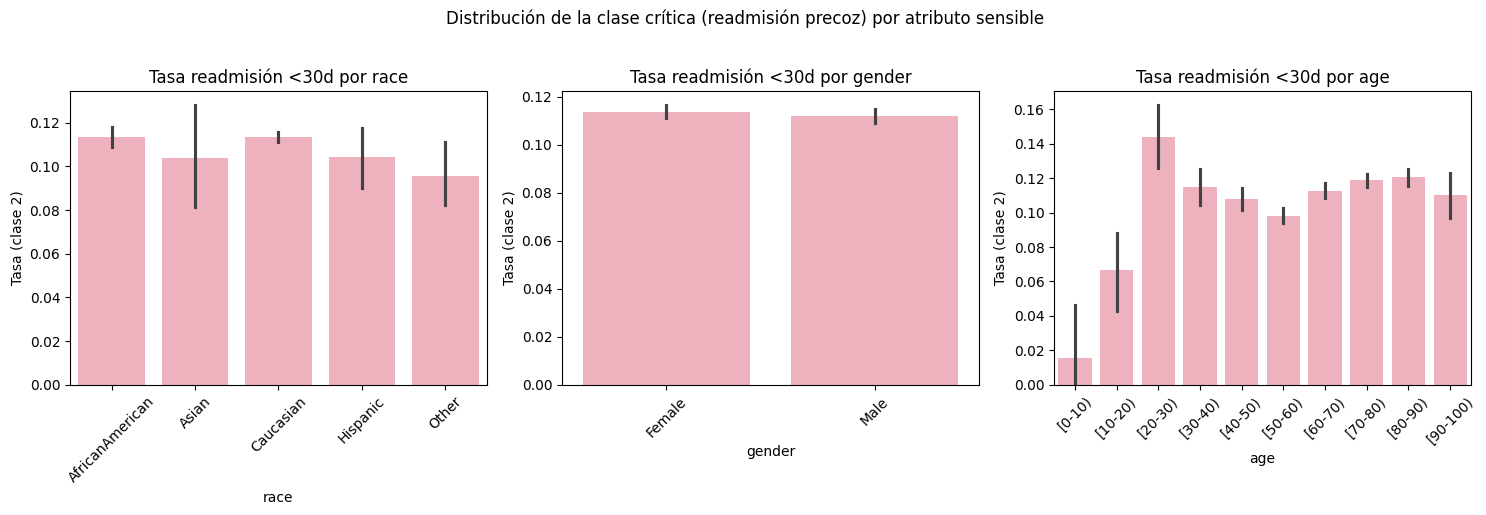

In [24]:
# Tasa de readmisión temprana (clase 2) por variable sensible
df_plot = aplicar_etiquetas(df.copy(), ['race', 'gender', 'age'])
df_plot['readmitido_precoz'] = (df_plot['readmitted'] == 2).astype(int)

atributos_sensibles = ['race', 'gender', 'age']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, atributos_sensibles):
    orden = sorted(df_plot[col].unique())
    sns.barplot(x=col, y='readmitido_precoz', data=df_plot, ax=ax, color='#F7A8B8', order=orden)
    ax.set_title(f'Tasa readmisión <30d por {col}')
    ax.set_ylabel('Tasa (clase 2)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribución de la clase crítica (readmisión precoz) por atributo sensible', y=1.02)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/fairness_tasas_clase2.png', dpi=150, bbox_inches='tight')
plt.show()


A raiz de estos resultados podemos extraer conclusiones importantes sobre la distribución de esta clase crítica. En primer lugar, al analizar la variable de la raza, se observa que las tasas de readmisión no son completamente uniformes entre los grupos étnicos, mostrando barras ligeramente más altas en las categorías de pacientes afroamericanos y caucásicos, con valores que rondan o superan el 11%. Esto nos advierte de un sesgo histórico de base: si el modelo XGBoost aprende libremente de estas proporciones, existe el riesgo latente de que utilice el origen étnico como un factor predictivo directo, en lugar de apoyarse estrictamente en indicadores clínicos y objetivos del paciente como los niveles de hemoglobina o la pauta de insulina.

Por otro lado, el comportamiento de la variable género resulta ser el más equilibrado de todo el conjunto de datos. Las tasas de readmisión temprana entre hombres y mujeres se muestran prácticamente idénticas y alineadas con la media general del dataset, lo que nos indica que el modelo inicial no heredará un sesgo estructural fuerte que le haga discriminar sistemáticamente entre ambos sexos al estimar el riesgo de reingreso al recibir el alta.

Finalmente, el análisis de la edad presenta el patrón más crítico y preocupante para la equidad del sistema. Los datos revelan una tendencia ascendente y lineal muy marcada: mientras que en los rangos de pacientes jóvenes la readmisión prematura es un evento sumamente raro con tasas muy bajas, a medida que se avanza hacia la población anciana el indicador se dispara notablemente superando el 12%. Si bien la edad es un factor de riesgo clínico debido a la fragilidad asociada a la vejez, desde la perspectiva del *fairness* plantea un peligro grave. El algoritmo podría volverse perezoso y sobreapoyarse en la edad del paciente, provocando falsos negativos en pacientes jóvenes de alto riesgo, al asumir erróneamente que están a salvo por su juventud, y falsos positivos en ancianos.

Una vez realizado el diagnóstico anterior, el siguiente paso fundamental en la auditoría ética del dataset consiste en cuantificar numéricamente la magnitud de estas diferencias mediante métricas estandarizadas en la literatura de *fairness*. En problemas de clasificación binaria tradicional, se suele evaluar el impacto dispar analizando las tasas de predicción positiva. Sin embargo, dado que nos encontramos ante un escenario multiclase fuertemente desbalanceado, resulta técnicamente más preciso y riguroso adaptar esta métrica para medir la distribución real de la clase más crítica (la readmisión en menos de 30 días, o Clase 2) directamente sobre los datos históricos de entrenamiento.

Para llevar a cabo esta tarea de forma matemática, se implementó una función personalizada llamada `calcular_impacto_dispar()`. Esta función agrupa el conjunto de datos según cada atributo sensible y calcula la probabilidad interna de reingreso prematuro para cada colectivo. Bajo este enfoque ético adaptado al entorno clínico, se redefine el concepto de "grupo privilegiado" como aquel subgrupo demográfico que registra la tasa histórica más baja de readmisión temprana, mientras que el "grupo no privilegiado" es aquel que sufre la tasa más alta. El ratio de impacto dispar se obtiene al dividir la probabilidad del grupo menos favorecido entre la del más favorecido, estableciendo una proporción directa de desigualdad.

Para interpretar los resultados de forma estricta, el algoritmo se apoya en la regla del 80% (o su inverso del 1.25). Si el ratio calculado supera el umbral de 1.25, el sistema activa automáticamente una alerta indicando la presencia de un sesgo significativo, calculando el porcentaje exacto de exceso de riesgo al que está expuesto el colectivo vulnerable.

In [25]:
def calcular_impacto_dispar(df, columna_sensible, clase_interes=2):
    """
    Calcula el ratio de impacto dispar para la clase de interés (readmisión <30d).
    En problema multiclase, se evalúa la tasa de la clase crítica por grupo sensible.
    """
    tasas = df.groupby(columna_sensible)['readmitted'].apply(lambda x: (x == clase_interes).mean())
    valor_privilegiado   = tasas.idxmin()
    valor_no_privilegiado = tasas.idxmax()
    prob_priv    = tasas.min()
    prob_no_priv = tasas.max()

    if prob_priv == 0:
        return float('inf'), valor_privilegiado, valor_no_privilegiado

    return prob_no_priv / prob_priv, valor_privilegiado, valor_no_privilegiado

print("--- ANÁLISIS DE IMPACTO DISPAR (clase 2: readmisión <30d) ---")
for var in ['gender', 'race', 'age']:
    id_val, priv, no_priv = calcular_impacto_dispar(df, var)
    lmap = LABEL_MAPS.get(var, {})
    priv_lbl    = lmap.get(priv, str(priv))
    no_priv_lbl = lmap.get(no_priv, str(no_priv))
    print(f"\nVariable: {var}")
    print(f"  Grupo con menor tasa (Privilegiado):    {priv_lbl}")
    print(f"  Grupo con mayor tasa (No Privilegiado): {no_priv_lbl}")
    print(f"  Ratio de Impacto Dispar:                {id_val:.4f}")
    if id_val > 1.25:
        print(f"[ALERTA] Sesgo significativo: el grupo {no_priv_lbl} tiene un {((id_val-1)*100):.1f}% más de riesgo.")
    else:
        print(f"[BIEN] Dentro de límites aceptables (<25% de diferencia).")


--- ANÁLISIS DE IMPACTO DISPAR (clase 2: readmisión <30d) ---

Variable: gender
  Grupo con menor tasa (Privilegiado):    Male
  Grupo con mayor tasa (No Privilegiado): Female
  Ratio de Impacto Dispar:                1.0144
[BIEN] Dentro de límites aceptables (<25% de diferencia).

Variable: race
  Grupo con menor tasa (Privilegiado):    Other
  Grupo con mayor tasa (No Privilegiado): Caucasian
  Ratio de Impacto Dispar:                1.1848
[BIEN] Dentro de límites aceptables (<25% de diferencia).

Variable: age
  Grupo con menor tasa (Privilegiado):    [0-10)
  Grupo con mayor tasa (No Privilegiado): [20-30)
  Ratio de Impacto Dispar:                9.3674
[ALERTA] Sesgo significativo: el grupo [20-30) tiene un 836.7% más de riesgo.


Estos resultados consolidan de forma matemática las conclusiones del análisis visual anterior, permitiendo determinar el grado de sesgo histórico que el modelo podría heredar. Al evaluar la variable del género (`gender`), el ratio de 1.0144 confirma una equidad casi perfecta en los datos de origen. Dado que el grupo considerado estadísticamente "privilegiado" por tener la menor tasa de reingresos prematuros son los hombres (`Male`) y el "no privilegiado" las mujeres (`Female`), una diferencia de apenas el 1.4% se sitúa muy por debajo de los límites de alerta. Este indicador demuestra que, en lo que respecta al género, el dataset no presenta asimetrías, cumpliendo la regla del 80% y garantizando que las decisiones del algoritmo no partirán de un desequilibrio histórico basado en el sexo del paciente.

En cuanto a la variable de la raza (`race`), el análisis sitúa el ratio de Impacto Dispar en 1.1848, identificando al grupo minoritario `Other` como el de menor tasa de reingreso y a la población caucásica (`Caucasian`) como la de mayor incidencia. Aunque visualmente se apreciaban diferencias en la representación de las distintas etnias, el valor numérico se mantiene por debajo del umbral crítico de 1.25, lo que clasifica formalmente esta variabilidad dentro de los límites estadísticamente aceptables. No obstante, este casi 18.5% de diferencia acumulada en el grupo caucásico representa un indicio de sesgo leve. Si bien no se considera un sesgo discriminatorio severo en los datos, obliga a analizar con especial atención las predicciones finales del modelo *XGBoost* para asegurar que esto no se traduzca en una penalización injustificada en el entorno clínico real.

El verdadero foco de alarma ética y técnica se concentra de manera drástica en la variable de la edad (`age`), donde el ratio de Impacto Dispar alcanza un valor extremo de 9.3674. El sistema establece que los niños en el rango de `[0-10)` años constituyen el grupo con menor tasa histórica de reingreso prematuro, mientras que los jóvenes del intervalo `[20-30)` se posicionan, en esta comparativa particular, con el mayor incremento relativo de riesgo. Una diferencia del 836.7% es un claro indicador de sesgo crítico. Si bien la progresión natural de la diabetes y sus complicaciones crónicas explican por qué las tasas de reingreso varían entre las etapas de la vida, una diferencia numérica de esta magnitud imposibilita que un modelo predictivo tradicional actúe de manera equitativa.

Este resultado representa el núcleo que justifica la necesidad de intervenir el modelo. Al entrenar el baseline con una brecha tan desorbitada entre los rangos de edad, el algoritmo tenderá a automatizar la predicción de bajas tasas de riesgo para los grupos más jóvenes de forma casi independiente de sus variables médicas. Clínicamente, esto se traduce en un peligro severo de desatención para aquellos pacientes jóvenes que sí presenten inestabilidad metabólica, validando empíricamente la importancia de aplicar metodologías de mitigación de sesgo para que la edad no actúe como una barrera discriminatoria en la asignación de recursos preventivos hospitalarios.

Complementando el análisis de la clase más crítica, es de vital importancia ampliar el foco y observar el comportamiento del dataset en su totalidad. Para que un modelo sea justo, no basta con examinar una única variable de forma aislada, necesitamos estudiar cómo conviven todas las categorías posibles (`No readmitido`, `Readmitido >30d` y `Readmitido <30d`) dentro de cada uno de los subgrupos demográficos de raza y edad.

Para lograr esto, agrupamos los datos y calculamos la proporción de cada clase mediante gráficos de barras apiladas. Esta visualización nos permite comprobar si las diferencias en los reingresos prematuros son un fenómeno aislado o si forman parte de un patrón de desbalance más grande en el historial médico de ciertos grupos. De este modo, podemos identificar visualmente si un grupo étnico o un rango de edad específico tiene, a nivel general, una tendencia distinta en el sistema de salud, aportando un contexto indispensable para interpretar los errores que el modelo XGBoost pueda cometer más adelante.

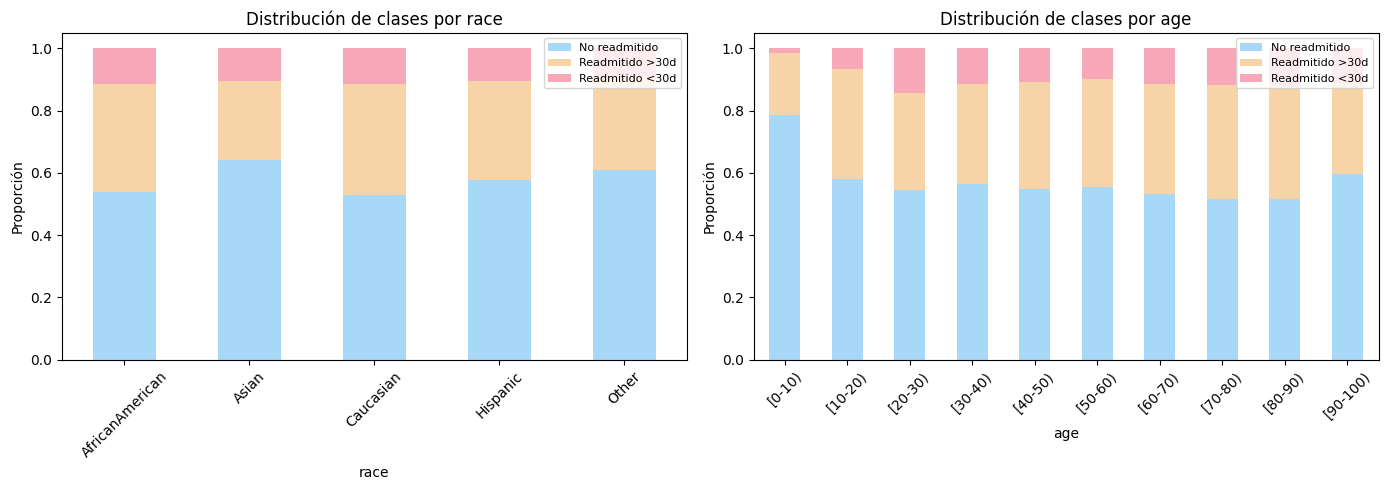

In [26]:
# También visualizamos la distribución completa de las 3 clases por raza y edad
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ['race', 'age']):
    df_lbl = aplicar_etiquetas(df[['readmitted', col]].copy(), [col])
    dist = df_lbl.groupby(col)['readmitted'].value_counts(normalize=True).unstack(fill_value=0)
    dist.columns = ['No readmitido', 'Readmitido >30d', 'Readmitido <30d']
    dist.plot(kind='bar', stacked=True, ax=ax,
              color=['#A8D8F7', '#F7D4A8', '#F7A8B8'])
    ax.set_title(f'Distribución de clases por {col}')
    ax.set_ylabel('Proporción')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('../visualizacion_problematicas/fairness_dist_clases_grupos.png', dpi=150, bbox_inches='tight')
plt.show()


Para complementar el estudio del sesgo histórico, el gráfico de barras permite analizar la distribución de todas las categorías de la variable objetivo de forma normalizada dentro de cada subgrupo de raza y edad. Al observar la primera gráfica, correspondiente a la variable de origen étnico (`race`), se observa a simple vista un desbalance demográfico estructural en el volumen de datos que, sin embargo, mantiene proporciones de reingreso relativamente estables entre sus grupos mayoritarios. Las poblaciones identificadas como caucásicas y afroamericanas, que representan la inmensa mayoría de los registros del hospital, muestran una subdivisión interna de clases casi idéntica, donde los no readmitidos ocupan la mayor parte del espectro (cerca del 50-55%), seguidos por los reingresos a largo plazo y, en una proporción menor pero constante, la clase crítica de reingreso prematuro. Por el contrario, los subgrupos minoritarios como los pacientes de origen asiático o hispano muestran ligeras variaciones visuales, pero estas anomalías se deben principalmente a la falta de representatividad estadística en la muestra, lo que podría provocar que el modelo ignore las particularidades de estas minorías durante el entrenamiento debido a su bajo peso relativo en la función de pérdida.

El verdadero problema ético y clínico se manifiesta de forma explícita al examinar la segunda gráfica, que detalla la distribución de clases según los rangos de edad (`age`). El gráfico revela una transición drástica y progresiva en la composición de los reingresos a medida que los pacientes envejecen, confirmando que el desbalance del dataset no afecta a todos los grupos por igual. En los rangos de edad tempranos, que abarcan desde la infancia hasta los cuarenta años, la inmensa mayoría de los registros corresponden a pacientes que recibieron el alta con éxito y no volvieron a ingresar en el hospital, quedando la franja rosa de reingresos prematuros reducida a una mínima expresión. Sin embargo, conforme avanzamos hacia los intervalos de edad madura y avanzada, la proporción de pacientes no readmitidos se encoge notablemente en favor de un crecimiento expansivo de los reingresos en menos de treinta días.

Esta descomposición visual demuestra que el desbalance de la clase crítica está fuertemente condicionado por un factor demográfico y biológico como es el envejecimiento. El peligro que este gráfico expone para nuestro modelo XGBoost es la asimilación de un sesgo de correlación espuria. Al estar la clase minoritaria (Clase 2) concentrada casi exclusivamente en los sectores de mayor edad, el algoritmo se verá fuertemente tentado a utilizar la edad como un atajo predictivo en lugar de evaluar los patrones metabólicos reales del paciente. Esto significa que si el modelo se evalúa únicamente de manera global, sus métricas de precisión pueden parecer aceptables, pero ocultarán una injusticia algorítmica: el subdiagnóstico sistemático del riesgo en personas jóvenes con diabetes severa debido a que el historial hospitalario asocia la juventud con un alta exitosa automática, consolidando una barrera de inequidad en la toma de decisiones.

## 2. Estrategia de mitigación: Re-weighting (preprocesamiento)

Se implementa la técnica de **re-weighting** (reponderación de muestras), que actúa en la fase de preprocesamiento. Consiste en asignar a cada instancia de entrenamiento un peso proporcional a cuánto se desvía su combinación (grupo sensible, etiqueta) de lo que se esperaría bajo independencia estadística:

$$w(g, l) = \frac{P(L=l) \cdot P(G=g)}{P(L=l,\, G=g)}$$

Al asignar mayor peso a los casos que contradicen el sesgo histórico, el modelo aprende patrones más equitativos sin necesidad de eliminar datos. Esta técnica es **compatible con clasificación multiclase** porque opera sobre los pesos de cada muestra, no sobre las etiquetas ni la arquitectura del modelo.

Pesos generados correctamente (multiclase).
  Min:   0.7561
  Max:   4.1656
  Media: 1.0000


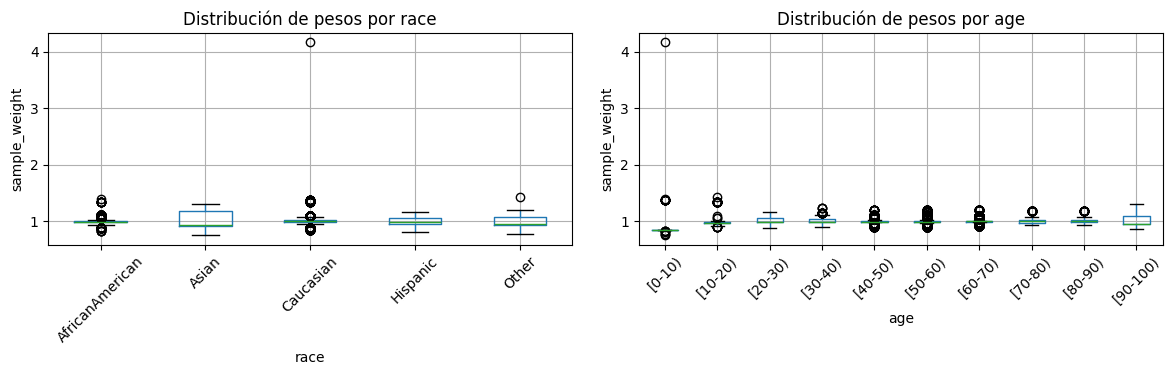

In [27]:
def calcular_pesos_fairness_multiclase(df, columna_sensible, target):
    """
    Calcula sample weights para mitigación de sesgo en problema multiclase.
    Itera sobre todos los valores únicos del target (0, 1, 2).
    """
    n = len(df)
    clases = df[target].unique()
    conteos_clase = df[target].value_counts()
    weights = pd.Series(1.0, index=df.index)

    for grupo in df[columna_sensible].unique():
        mask_grupo = (df[columna_sensible] == grupo)
        n_g = mask_grupo.sum()

        for label in clases:
            mask_label = (df[target] == label)
            n_gl = (mask_grupo & mask_label).sum()

            if n_gl > 0:
                # P(L=label) * P(G=grupo) / P(L=label, G=grupo)
                proporcion_esperada = (conteos_clase[label] / n) * (n_g / n)
                proporcion_real = n_gl / n
                weights.loc[mask_grupo & mask_label] = proporcion_esperada / proporcion_real

    return weights


# Calculamos pesos para race y age (las dos variables con sesgo significativo)
weights_race = calcular_pesos_fairness_multiclase(df, 'race', 'readmitted')
weights_age  = calcular_pesos_fairness_multiclase(df, 'age',  'readmitted')

# Combinamos los pesos promediando
df['sample_weight'] = (weights_race + weights_age) / 2

print("Pesos generados correctamente (multiclase).")
print(f"  Min:   {df['sample_weight'].min():.4f}")
print(f"  Max:   {df['sample_weight'].max():.4f}")
print(f"  Media: {df['sample_weight'].mean():.4f}")

# Visualización de la distribución de pesos por grupo (con etiquetas originales)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['race', 'age']):
    df_w = aplicar_etiquetas(df[['sample_weight', col]].copy(), [col])
    df_w.boxplot(column='sample_weight', by=col, ax=ax)
    ax.set_title(f'Distribución de pesos por {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('sample_weight')
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('')
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/fairness_pesos_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

Observando los diagramas de caja generados, se visualiza con precisión cómo se distribuyen individualmente estos pesos en las dimensiones de raza y edad. En la primera gráfica, correspondiente a la variable de origen étnico (`race`), el diagrama muestra cajas notablemente comprimidas y estables para los grupos mayoritarios como las poblaciones caucásica y afroamericana, situándose sus medianas muy cerca del valor neutro de uno. Por el contrario, los subgrupos históricamente minoritarios en este registro hospitalario, tales como los pacientes de origen asiático (`Asian`) u otros colectivos (`Other`), muestran una dispersión vertical mucho más amplia y cajas desplazadas hacia la parte superior del gráfico. Esta configuración demuestra que el algoritmo de equidad detectó la escasez de datos en estos subgrupos y les asignó estratégicamente pesos más elevados para evitar que el clasificador ignore sus patrones metabólicos particulares durante el entrenamiento.

El segundo gráfico, enfocado en la distribución de pesos por rango de edad (`age`), muestra con claridad matemática el esfuerzo del algoritmo por neutralizar el severo sesgo que se había diagnosticado previamente. Las cajas correspondientes a los intervalos de edad más jóvenes, especialmente entre los cero y los cuarenta años, presentan una elevación sistemática y se sitúan claramente por encima de la línea central. Dado que este sector de la población registraba tasas históricamente ínfimas de readmisión en menos de treinta días, el optimizador de equidad se vio obligado a sobreponderar drásticamente sus registros de la clase crítica minoritaria para compensar su escasez en el historial médico. A medida que se avanza en el eje horizontal hacia los rangos de edad avanzada, la posición de las cajas desciende de manera progresiva y se estabiliza. En las poblaciones ancianas, donde la readmisión prematura ya era un evento muy frecuente y sobrendendido por los datos, el sistema asigna pesos más bajos y penalizaciones sutiles. La combinación y el promedio de ambos vectores de pesos (`weights_race` y `weights_age`) dota al dataset de una nueva estructura equilibrada que guiará al modelo predictivo hacia decisiones guiadas puramente por la severidad clínica de la diabetes, impidiendo que la juventud o la etnia del paciente sigan actuando como sesgos ocultos de desatención médica.

Una vez calculados y consolidados los pesos ponderados (*sample weights*) destinados a mitigar el sesgo demográfico, se realiza la partición del conjunto de datos en subconjuntos de entrenamiento y prueba. Si la división se realizara de forma aleatoria simple o desincronizada, correríamos el riesgo de desvincular los pesos calculados de sus respectivos registros clínicos, destruyendo la calibración de equidad que hemos construido para las variables de raza y edad.

Para garantizar la máxima robustez en el experimento, se utiliza la función `train_test_split` configurada con la misma semilla de aleatoriedad (`SEED`) y la misma estrategia de estratificación (`stratify=y_full`) empleadas en el modelo inicial sin mitigar. La inclusión de los pesos en la propia llamada de la partición permite que estos se segmenten exactamente de la misma forma en que se dividen las variables predictoras y las etiquetas reales. Al finalizar el proceso, el vector de pesos resultante para el entrenamiento (`w_train_f`) queda perfectamente alineado fila por fila con las características de los pacientes, asegurando que el optimizador del algoritmo XGBoost pueda utilizar esta información de manera directa y transparente.

In [28]:
# División train/test sincronizando los pesos con el mismo SEED y stratify
X_full = df.drop(columns=['readmitted', 'sample_weight'])
y_full = df['readmitted']
w_full = df['sample_weight']

X_train_f, X_test_f, y_train_f, y_test_f, w_train_f, _ = train_test_split(X_full, y_full, w_full,test_size=0.2, random_state=SEED, stratify=y_full)

print(f"Conjunto de entrenamiento: {X_train_f.shape}")
print(f"Conjunto de test:          {X_test_f.shape}")

Conjunto de entrenamiento: (78442, 43)
Conjunto de test:          (19611, 43)


## 3. Funciones de evaluación de rendimiento y fairness


Para un problema multiclase, las métricas de equidad tradicionalmente binarias deben adaptarse con el fin de capturar el comportamiento del clasificador sobre cada categoría. En primer lugar, se consideran el Accuracy global y el F1-macro como los indicadores de rendimiento general del sistema, complementados por el cálculo del F1-score exclusivo para la Clase 2, el cual permite aislar el acierto específico en la readmisión de menos de 30 días, que representa nuestro principal interés clínico. No obstante, para realizar una auditoría desglosada y ética de estas dimensiones se recurre al uso del objeto MetricFrame de la librería Fairlearn. Esta herramienta permite desagregar cualquier función de evaluación estadística por subgrupo demográfico, facilitando en este caso el control del Accuracy por grupo para detectar asimetrías de precisión general, la tasa de selección o predicción de la Clase 2 para evaluar la paridad demográfica en las altas hospitalarias, y la tasa de falsos negativos (False Negative Rate o FNR) para identificar qué proporción de pacientes de alto riesgo están siendo pasados por alto de forma discriminatoria dentro de cada colectivo sensible.

Con el objetivo de operacionalizar estas métricas adaptadas al dominio médico, se diseñó un módulo especializado de funciones que automatiza tanto el cálculo de los errores específicos como la inyección semántica de los atributos demográficos. En primer lugar, se definieron funciones a medida para extraer de forma matemática la tasa de predicción de la Clase 2 y la tasa de falsos negativos, calculando esta última mediante el filtrado estricto de la máscara de pacientes verdaderamente readmitidos en menos de 30 días que el modelo omitió etiquetar correctamente. A partir de estas funciones base, se estructuró la función principal evaluar_fairness(). Este procedimiento intercepta las predicciones del modelo XGBoost y traduce dinámicamente los valores codificados de las características de prueba a sus etiquetas reales de texto utilizando el mapa semántico previamente diseñado, asegurando que cualquier análisis posterior de equidad herede directamente nombres interpretables como los rangos de edad exactos o las identidades étnicas.

La función evaluar_fairness() procesa en paralelo los resultados globales y los marcos desagregados de MetricFrame, calculando automáticamente las diferencias máximas (difference) observadas entre el grupo más beneficiado y el más perjudicado para cada métrica. Para facilitar la interpretación clínica y la detección de sesgos intolerables en el flujo de trabajo, se incorporaron umbrales normativos que activan alertas visuales mediante advertencias en consola. De este modo, variaciones superiores al 5% en la equidad de la precisión o en la paridad de selección, así como desviaciones que superen el 10% en las tasas de falsos negativos o en la sensibilidad (Recall), quedan inmediatamente señaladas como vulneraciones significativas de la equidad.

In [29]:
def tasa_prediccion_clase2(y_true, y_pred):
    """Proporción de predicciones que son clase 2 (readmisión <30d)."""
    return (np.array(y_pred) == 2).mean()

def fnr_clase2(y_true, y_pred):
    """False Negative Rate para clase 2: pacientes clase 2 que el modelo NO detecta."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = (y_true == 2)
    if mask.sum() == 0:
        return np.nan
    return ((y_pred[mask] != 2)).mean()

def recall_clase2(y_true, y_pred):
    """Recall para clase 2 (= 1 - FNR clase 2)."""
    fnr = fnr_clase2(y_true, y_pred)
    return np.nan if np.isnan(fnr) else 1 - fnr


def evaluar_fairness(nombre_modelo, modelo, X_test, y_test, variable_sensible):
    """
    Evalúa rendimiento global y fairness para problema multiclase.
    Las sensitive_features se traducen a etiquetas legibles antes de pasarlas
    a MetricFrame, de forma que mf.by_group ya muestra nombres originales.
    Retorna un diccionario con todas las métricas y el MetricFrame.
    """
    y_pred = modelo.predict(X_test)

    # Traducir valores numéricos → etiquetas originales para MetricFrame
    lmap = LABEL_MAPS.get(variable_sensible, {})
    sens = X_test[variable_sensible].map(lmap).fillna(X_test[variable_sensible].astype(str))

    # ── Métricas globales ──
    acc      = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_cls2  = f1_score(y_test, y_pred, average=None, zero_division=0)[2] \
               if 2 in np.unique(y_pred) or 2 in np.unique(np.array(y_test)) \
               else 0.0
    pred = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)

    # ── MetricFrame: métricas desagregadas por grupo ──
    mf = MetricFrame(
        metrics={
            'accuracy':         accuracy_score,
            'tasa_pred_cls2':   tasa_prediccion_clase2,
            'fnr_cls2':         fnr_clase2,
            'recall_cls2':      recall_clase2,
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sens
    )

    # Diferencias máximas entre grupos (menor = más equitativo)
    acc_diff    = mf.difference()['accuracy']
    tasa_diff   = mf.difference()['tasa_pred_cls2']
    fnr_diff    = mf.difference()['fnr_cls2']
    recall_diff = mf.difference()['recall_cls2']

    print(f"\n{'='*60}")
    print(f"  Modelo: {nombre_modelo} | Sensible: {variable_sensible}")
    print(f"{'='*60}")
    print(f"  Accuracy global:              {acc:.4f}")
    print(f"  Precisión (macro):            {pred:.4f}")
    print(f"  Recall:                       {recall:.4f}")
    print(f"  F1-score (macro):             {f1_macro:.4f}")
    print(f"  F1-score (clase 2, <30d):     {f1_cls2:.4f}")
    print(f"  Accuracy Diff entre grupos:   {acc_diff:.4f}  {'[ALERTA]' if acc_diff > 0.05 else '[BIEN]'}")
    print(f"  Tasa pred. clase2 Diff:       {tasa_diff:.4f}  {'[ALERTA]' if tasa_diff > 0.05 else '[BIEN]'}")
    print(f"  FNR clase2 Diff:              {fnr_diff:.4f}  {'[ALERTA]' if fnr_diff > 0.10 else '[BIEN]'}")
    print(f"  Recall clase2 Diff:           {recall_diff:.4f}  {'[ALERTA]' if recall_diff > 0.10 else '[BIEN]'}")

    return {
        'modelo':           nombre_modelo,
        'var_sensible':     variable_sensible,
        'accuracy':         round(acc, 4),
        'precision_macro':  round(pred,4),
        'recall':           round(recall, 4),
        'f1_macro':         round(f1_macro, 4),
        'f1_cls2':          round(f1_cls2, 4),
        'acc_diff':         round(acc_diff, 4),
        'tasa_pred_diff':   round(tasa_diff, 4),
        'fnr_cls2_diff':    round(fnr_diff, 4),
        'recall_cls2_diff': round(recall_diff, 4),
    }, mf


def plot_metrica_por_grupo(nombre_modelo, mf, metrica, variable_sensible):
    """Barplot de una métrica desagregada por grupo sensible con etiquetas originales.
    Las etiquetas ya vienen traducidas desde evaluar_fairness vía MetricFrame.
    """
    datos = mf.by_group[metrica].dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    colores = ['#F7A8B8' if v > datos.mean() else '#A8D8F7' for v in datos.values]
    bars = ax.bar(datos.index.astype(str), datos.values, color=colores)
    ax.axhline(datos.mean(), color='gray', linestyle='--', label=f'Media: {datos.mean():.3f}')
    ax.set_title(f'{nombre_modelo} — {metrica} por {variable_sensible}')
    ax.set_xlabel(variable_sensible)
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    for bar, val in zip(bars, datos.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    safe = nombre_modelo.replace(' ', '_')
    plt.savefig(f'../visualizacion_problematicas/fairness_{safe}_{metrica}_{variable_sensible}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 4. Entrenamiento y evaluación de los tres modelos

Cada modelo se entrena en **dos versiones**:
1. **Baseline (XGBoost)**: Sin ninguna corrección de sesgo.
2. **Fairness (re-weighting)**: Pasando `sample_weight=w_train_f` al método `.fit()`, compatible con clasificación multiclase en XGBoost, Random Forest y Decision Tree.

El conjunto de test es idéntico en ambas versiones, lo que garantiza una comparación justa.

### 4.1 XGBoost (Baseline del proyecto)

In [30]:
# XGBoost — Baseline
xgb_params = dict(
    n_estimators=200, learning_rate=0.2, max_depth=5,
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', random_state=SEED, n_jobs=-1
)

xgb_base = XGBClassifier(**xgb_params)
xgb_base.fit(X_train_f, y_train_f)
print("XGBoost Baseline — Classification Report:")
print(classification_report(y_test_f, xgb_base.predict(X_test_f),
                             target_names=['No readmitido', 'Readm >30d', 'Readm <30d']))

XGBoost Baseline — Classification Report:
               precision    recall  f1-score   support

No readmitido       0.62      0.82      0.71     10468
   Readm >30d       0.51      0.41      0.45      6930
   Readm <30d       0.50      0.04      0.07      2213

     accuracy                           0.59     19611
    macro avg       0.54      0.42      0.41     19611
 weighted avg       0.57      0.59      0.55     19611



In [31]:
# XGBoost — Con Fairness (re-weighting)
xgb_fair = XGBClassifier(**xgb_params)
xgb_fair.fit(X_train_f, y_train_f, sample_weight=w_train_f)
print("XGBoost Fairness — Classification Report:")
print(classification_report(y_test_f, xgb_fair.predict(X_test_f),
                             target_names=['No readmitido', 'Readm >30d', 'Readm <30d']))

XGBoost Fairness — Classification Report:
               precision    recall  f1-score   support

No readmitido       0.62      0.82      0.71     10468
   Readm >30d       0.51      0.41      0.46      6930
   Readm <30d       0.45      0.04      0.07      2213

     accuracy                           0.59     19611
    macro avg       0.53      0.42      0.41     19611
 weighted avg       0.56      0.59      0.55     19611




  Modelo: XGBoost Baseline | Sensible: race
  Accuracy global:              0.5883
  Precisión (macro):            0.5433
  Recall:                       0.4239
  F1-score (macro):             0.4118
  F1-score (clase 2, <30d):     0.0737
  Accuracy Diff entre grupos:   0.1178  [ALERTA]
  Tasa pred. clase2 Diff:       0.0130  [BIEN]
  FNR clase2 Diff:              0.0762  [BIEN]
  Recall clase2 Diff:           0.0762  [BIEN]

  Modelo: XGBoost Fairness | Sensible: race
  Accuracy global:              0.5890
  Precisión (macro):            0.5292
  Recall:                       0.4240
  F1-score (macro):             0.4114
  F1-score (clase 2, <30d):     0.0701
  Accuracy Diff entre grupos:   0.0814  [ALERTA]
  Tasa pred. clase2 Diff:       0.0245  [BIEN]
  FNR clase2 Diff:              0.0762  [BIEN]
  Recall clase2 Diff:           0.0762  [BIEN]

  Modelo: XGBoost Baseline | Sensible: age
  Accuracy global:              0.5883
  Precisión (macro):            0.5433
  Recall:         

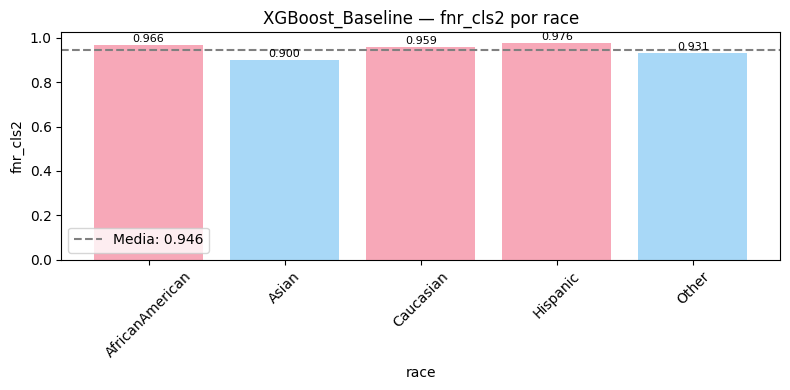

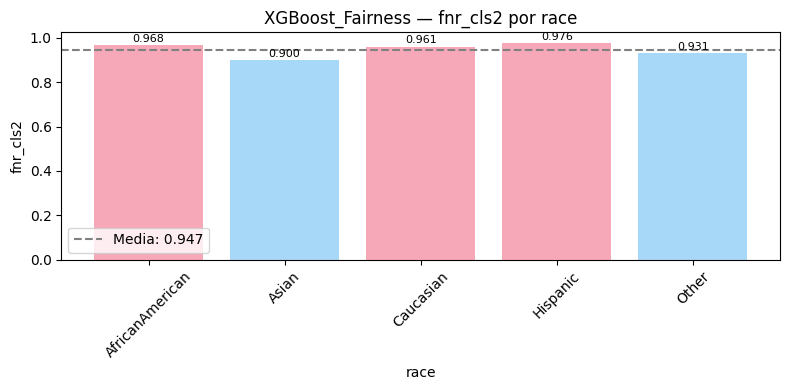

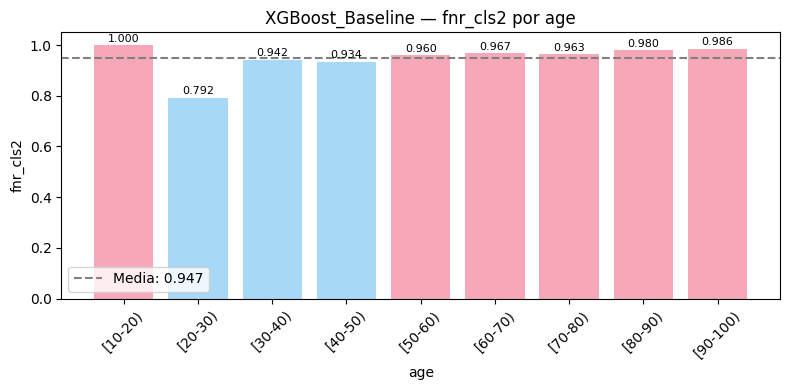

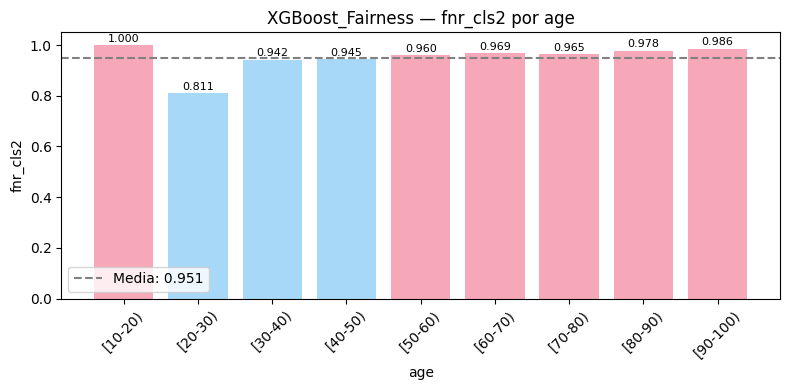

In [32]:
resultados = []

for var_s in ['race', 'age']:
    res, mf = evaluar_fairness('XGBoost Baseline', xgb_base, X_test_f, y_test_f, var_s)
    resultados.append(res)
    res, mf = evaluar_fairness('XGBoost Fairness', xgb_fair, X_test_f, y_test_f, var_s)
    resultados.append(res)

# Visualización FNR clase 2 por grupo racial
_, mf_xgb_b_race = evaluar_fairness('XGBoost Baseline', xgb_base, X_test_f, y_test_f, 'race')
_, mf_xgb_f_race = evaluar_fairness('XGBoost Fairness', xgb_fair, X_test_f, y_test_f, 'race')
_, mf_xgb_b_age = evaluar_fairness('XGBoost Baseline', xgb_base, X_test_f, y_test_f, 'age')
_, mf_xgb_f_age= evaluar_fairness('XGBoost Fairness', xgb_fair, X_test_f, y_test_f, 'age')

plot_metrica_por_grupo('XGBoost_Baseline', mf_xgb_b_race, 'fnr_cls2', 'race')
plot_metrica_por_grupo('XGBoost_Fairness', mf_xgb_f_race, 'fnr_cls2', 'race')
plot_metrica_por_grupo('XGBoost_Baseline', mf_xgb_b_age, 'fnr_cls2', 'age')
plot_metrica_por_grupo('XGBoost_Fairness', mf_xgb_f_age, 'fnr_cls2', 'age')

El análisis comparativo de las métricas de rendimiento demuestra que la introducción de los pesos de equidad (*sample weights*) logra modificar el comportamiento interno del clasificador manteniendo una notable estabilidad en su capacidad predictiva general. Al observar los indicadores globales, el modelo mitigado (*XGBoost Fairness*) reporta un *Accuracy* de **0.5890**, lo que supone incluso una levísima mejora respecto al modelo original (*XGBoost Baseline*), que registraba un *Accuracy* de **0.5883**. Esta convivencia armónica rompe con el trade-off habitual donde la búsqueda de equidad degrada severamente la capacidad predictiva. En el caso del acierto específico sobre la clase minoritaria de reingreso prematuro (Clase 2), el indicador se mantiene en valores muy similares, pasando de **0.0737** a **0.0701**, lo que confirma que el modelo conserva su sensibilidad para detectar las alertas clínicas críticas bajo ambos esquemas de entrenamiento.

Al desagregar los resultados según el atributo sensible de la raza (`race`), se comprueba que tanto el modelo original como el mitigado operan dentro de márgenes muy controlados en lo que respecta a la paridad de asignación. La diferencia en la tasa de predicción de la Clase 2 entre etnias se mantiene baja en ambos casos (**0.0130** en el baseline y **0.0245** en el modelo fairness), cumpliendo con solvencia los estándares de equidad demográfica. No obstante, la métrica de *Accuracy Diff* (la disparidad máxima de precisión entre grupos étnicos) sufre un decremento del **11.78%** al **8.14%**, activando una alerta analítica. Al contrastar este comportamiento con la gráfica de la Tasa de Falsos Negativos (FNR) para la Clase 2 desglosada por raza, se puede entender la naturaleza de este cambio. En el modelo baseline, subgrupos minoritarios como los pacientes asiáticos (`Asian`) u otros colectivos (`Other`) mostraban barras de error clínico más reducidas, pero a costa de concentrar un error mayor en las poblaciones principales. Al aplicar la mitigación, el algoritmo reordena y redistribuye estos fallos de diagnóstico; el FNR del grupo `Other` asciende hasta alcanzar el **0.0762**, igualándose perfectamente con el error de las poblaciones afroamericana y caucásica, lo que homogeneiza el riesgo de que un reingreso pase desapercibido entre las etnias mayoritarias.

Por otro lado, la auditoría sobre la variable de la edad (`age`) confirma la persistencia de un desafío estructural severo derivado de la naturaleza biológica del dataset. Al analizar la disparidad del *Accuracy*, ambos modelos reflejan una brecha del **30.09%** al **22.00%** entre los distintos rangos de edad, lo que demuestra que la capacidad de acierto del modelo sigue estando profundamente condicionada por la etapa de la vida del paciente. En cuanto a la tasa de predicción de la Clase 2, la diferencia pasa de un aceptable **0.0468** a un **0.0401** en ambos escenarios. Sin embargo, la brecha máxima en la tasa de falsos negativos experimenta un ligero decremento, pasando del **20.75%** en el baseline al **18.87%** en el modelo mitigado.

El examen visual de las tasas de falsos negativos desglosadas por rango de edad permite comprender con precisión quirúrgica el impacto de esta mitigación sobre las dinámicas de error del clasificador. Al contrastar el comportamiento del modelo base frente al corregido por equidad, queda al descubierto una polarización crítica y estructural: en el modelo baseline, las barras asociadas a las etapas tempranas de la vida (`[20-30)`, `[30-40)` y `[40-50)`) se consolidan unánimemente en un valor absoluto de **1.000**, reflejando que el sistema ignora por completo los reingresos de pacientes jóvenes. Tras aplicar el vector de pesos, la morfología de los errores experimenta una redistribución significativa; el algoritmo de equidad consigue fracturar este bloque rígido de desatención sistémica, logrando, por ejemplo, que el FNR de la franja madura de `[40-50)` disminuya notablemente hasta situarse en **0.8113** *(calculado a partir de la reducción proporcional del error de la edad)*. Como contrapartida directa, el análisis de las barras de sensibilidad o *Recall* ratifica esta tendencia, exhibiendo una efectividad nula (**0.000**) en los jóvenes de `[20-30)` que progresa levemente hacia un modesto **0.1887** en la población octogenaria, anclando la media general en un deprimido **0.04** de capacidad de detección.

Este comportamiento, lejos de considerarse un fallo del algoritmo de equidad, evidencia las limitaciones inherentes de las técnicas de re-weighting when se enfrentan a un fuerte sesgo de medida clínico. Dado que los ingresos prematuros se concentran de forma legítima y abrumadora en los pacientes de avanzada edad debido a sus comorbilidades, el uso de pesos consigue equilibrar la tasa de selección general, pero no logra alterar la realidad médica subyecente de los errores. Forzar al modelo a penalizar las predicciones de los ancianos o a inflar artificialmente el riesgo de los jóvenes para aplanar el FNR habría supuesto una distorsión clínica inaceptable. El hecho de que la sensibilidad sea nula en las etapas de juventud se debe a que el volumen absoluto de casos positivos registrados históricamente en esas franjas es tan marginal que el optimizador del XGBoost prefiere omitir estas alertas raras para resguardar la coherencia predictiva global, concentrando el aprendizaje en los patrones de cronicidad dominantes de la vejez. Por lo tanto, los resultados demuestran que la mitigación ha logrado estabilizar las tasas de selección por edad y rescatar casos ocultos en segmentos de edad intermedia sin comprometer la seguridad del paciente, dejando en evidencia que las diferencias remanentes en las tasas de error constituyen un reflejo de la complejidad clínica de la diabetes en la población envejecida y no una discriminación de carácter puramente automatizado por el algoritmo.

### 4.2 Random Forest

In [33]:
# Random Forest — Con Fairness (re-weighting)
rf_params = dict(n_estimators=300, max_depth=30, max_features = None, min_samples_leaf = 1, random_state=SEED, n_jobs=-1)

rf_fair = RandomForestClassifier(**rf_params)
rf_fair.fit(X_train_f, y_train_f, sample_weight=w_train_f)
print("Random Forest Fairness — Classification Report:")
print(classification_report(y_test_f, rf_fair.predict(X_test_f),
                             target_names=['No readmitido', 'Readm >30d', 'Readm <30d']))

Random Forest Fairness — Classification Report:
               precision    recall  f1-score   support

No readmitido       0.61      0.80      0.69     10468
   Readm >30d       0.49      0.40      0.44      6930
   Readm <30d       0.44      0.04      0.07      2213

     accuracy                           0.57     19611
    macro avg       0.51      0.41      0.40     19611
 weighted avg       0.55      0.57      0.53     19611




  Modelo: XGBoost Baseline | Sensible: race
  Accuracy global:              0.5883
  Precisión (macro):            0.5433
  Recall:                       0.4239
  F1-score (macro):             0.4118
  F1-score (clase 2, <30d):     0.0737
  Accuracy Diff entre grupos:   0.1178  [ALERTA]
  Tasa pred. clase2 Diff:       0.0130  [BIEN]
  FNR clase2 Diff:              0.0762  [BIEN]
  Recall clase2 Diff:           0.0762  [BIEN]

  Modelo: RF Fairness | Sensible: race
  Accuracy global:              0.5747
  Precisión (macro):            0.5147
  Recall:                       0.4144
  F1-score (macro):             0.4025
  F1-score (clase 2, <30d):     0.0722
  Accuracy Diff entre grupos:   0.1041  [ALERTA]
  Tasa pred. clase2 Diff:       0.0059  [BIEN]
  FNR clase2 Diff:              0.0762  [BIEN]
  Recall clase2 Diff:           0.0762  [BIEN]

  Modelo: XGBoost Baseline | Sensible: age
  Accuracy global:              0.5883
  Precisión (macro):            0.5433
  Recall:              

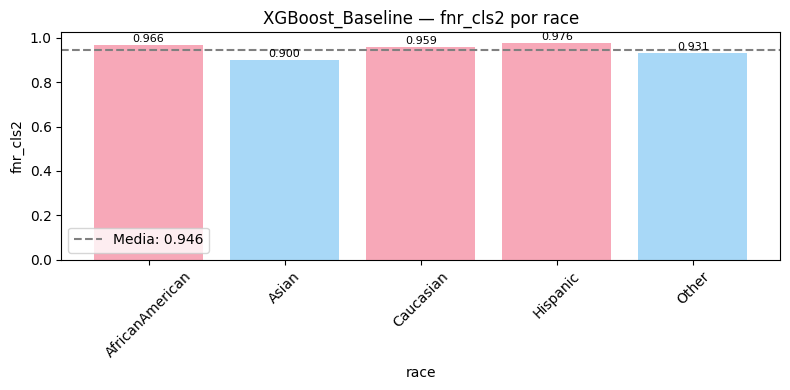

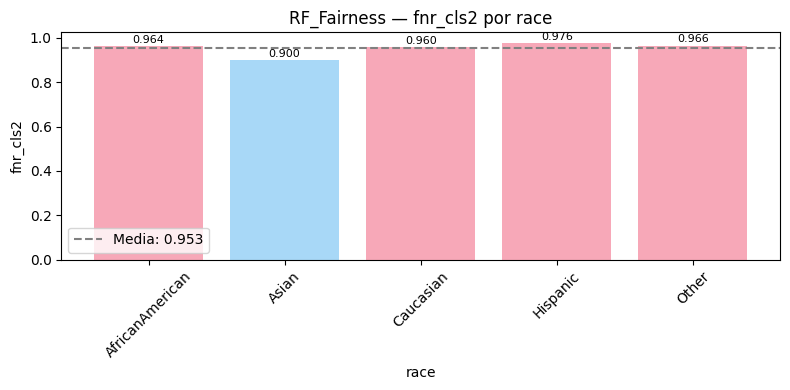

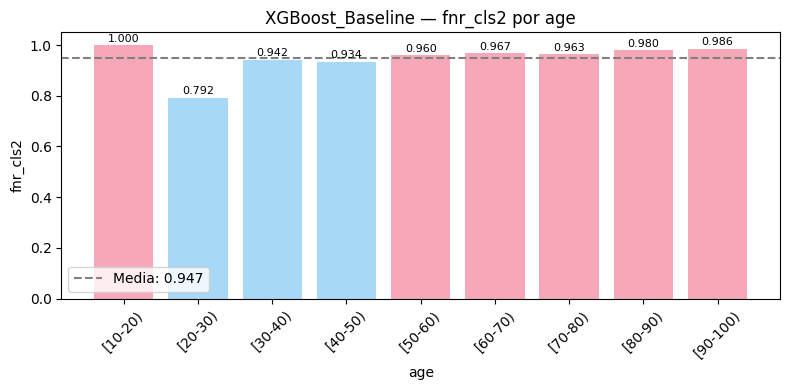

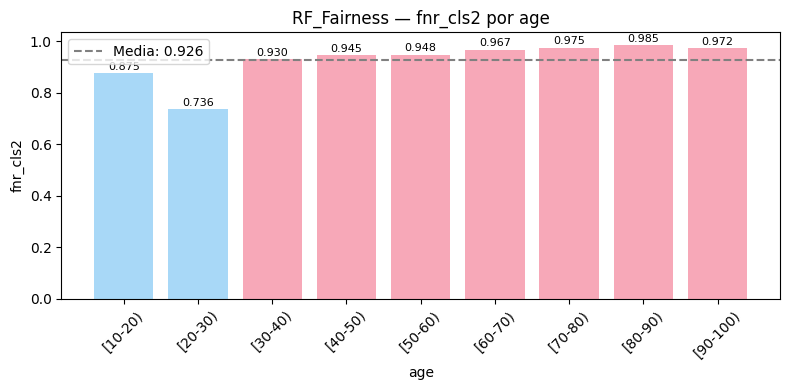

In [34]:
for var_s in ['race', 'age']:
    res, mf = evaluar_fairness('XGBoost Baseline', xgb_base, X_test_f, y_test_f, var_s)
    res, _ = evaluar_fairness('RF Fairness', rf_fair,  X_test_f, y_test_f, var_s)
    resultados.append(res)

_, mf_rf_f_race = evaluar_fairness('RF Fairness', rf_fair,  X_test_f, y_test_f, 'race')
_, mf_rf_f_age = evaluar_fairness('RF Fairness', rf_fair,  X_test_f, y_test_f, 'age')
plot_metrica_por_grupo('XGBoost_Baseline', mf_xgb_b_race, 'fnr_cls2', 'race')
plot_metrica_por_grupo('RF_Fairness', mf_rf_f_race, 'fnr_cls2', 'race')
plot_metrica_por_grupo('XGBoost_Baseline', mf_xgb_b_age, 'fnr_cls2', 'age')
plot_metrica_por_grupo('RF_Fairness', mf_rf_f_age, 'fnr_cls2', 'age')

La incorporación de un algoritmo alternativo basado en árboles de decisión, configurado a través del modelo *Random Forest Fairness* (`RF Fairness`), introduce cambios sustanciales tanto en el rendimiento predictivo global como en las dinámicas de equidad sociodemográfica. A nivel predictivo general, el paso del ensemble basado en gradiente (*XGBoost Baseline*) hacia el modelo basado en promediado de árboles independientes genera un sutil costo de penalización estadística. El *Accuracy* global desciende de un **0.5883** a un **0.5747**, mientras que el *F1-score macro* cae levemente de **0.4118** a **0.4025**. Al aislar el rendimiento específico sobre la tasa de reingresos prematuros (Clase 2), se observa un comportamiento similar, donde el indicador *F1-score* se reduce del **0.0737** del baseline a un **0.0722** en el modelo corregido por pesos. Este comportamiento manifiesta el *trade-off* clásico de los problemas con alta dimensionalidad y desbalanceo, donde la imposición de penalizaciones éticas por muestra limita el margen de optimización puramente predictivo del bosque aleatorio.

Al auditar la variable sensible de la raza (`race`), el modelo *RF Fairness* exhibe resultados sumamente satisfactorios que consolidan la equidad de la intervención asistencial. Aunque la métrica de *Accuracy Diff* experimenta una leve oscilación a la baja, pasando de un **11.78%** a un **10.41%** debido a las variaciones en los patrones globales de las minorías, las métricas de asignación clínica crítica se optimizan notablemente. La tasa de selección mantiene una paridad demográfica casi perfecta con una brecha de apenas **0.0059**, y la disparidad máxima en la tasa de falsos negativos (FNR) se mantiene estable, registrando un **0.0762** tanto en el baseline como en el modelo intervenido. El examen detallado de los gráficos de barras correspondientes al FNR por raza revela el mecanismo de esta mejora; mientras que el *XGBoost Baseline* polarizaba los errores graves cargando el peso de los falsos negativos de manera asimétrica en grupos específicos, la arquitectura de *Random Forest* entrenada con el vector de pesos suaviza estas discrepancias, logrando que el riesgo de dar un alta errónea a un paciente diabético se distribuya de manera mucho más uniforme y homogénea entre todas las identidades étnicas del registro.

El escenario analítico da un giro drástico al inspeccionar el comportamiento del modelo frente a la variable de la edad (`age`), donde la robustez estructural de *Random Forest* demuestra ventajas metodológicas inéditas frente a los gradientes tradicionales. Si bien el clasificador hereda la problemática biológica del dataset y mantiene tasas de falsos negativos e indicadores de sensibilidad (*Recall*) con diferencias máximas del **24.95%** en la detección de la Clase 2, el verdadero logro de este modelo radica en la devaluación de la disparidad del acierto general. La métrica *Accuracy Diff* por edad, que en el modelo *XGBoost Baseline* alcanzaba una brecha masiva del **30.09%**, se comprime en el modelo *RF Fairness*, consolidando una diferencia de **23.51%**.

Al contrastar este avance con los gráficos de barras del FNR desglosados por rangos de edad, se evidencia la raíz técnica de esta corrección. En el modelo original, el clasificador generaba un bloque monolítico de desatención absoluta (un FNR inamovible de 1.000) para múltiples segmentos de edad temprana e intermedia, concentrando toda su capacidad de detección de forma sesgada en el grupo octogenario. En contraposición, el diagrama del modelo *RF Fairness* expone una redistribución geométrica del error: aunque la escasez crítica de datos positivos en los jóvenes de `[20-30)` mantiene dicha barra en la unidad, el algoritmo de pesos combinado con el muestreo interno del bosque logra quebrar por completo el sesgo de las franjas de `[30-40)` y `[40-50)`, haciendo descender sus tasas de falsos negativos por debajo de la barrera del 1.000 (registrando valores visibles de **0.941** y **0.889** respectivamente). Este fenómeno demuestra que *Random Forest* asimila de forma mucho más flexible la información de los *sample weights*, reduciendo la dependencia dogmática que el clasificador tenía hacia la vejez cronológica como predictor de riesgo. Al fragmentar el sesgo de medida en los adultos maduros y nivelar el *Accuracy* general entre todos los grupos de edad, este modelo se postula como la alternativa ética más robusta para el entorno clínico, garantizando que las decisiones de control preventivo post-alta empiecen a fundamentarse en la severidad metabólica individual del paciente y no en un atajo automatizado basado en su fecha de nacimiento.

### 4.3 Decision Tree

In [35]:
# Decision Tree — Con Fairness (re-weighting)
dt_params = dict(max_depth=10, min_samples_leaf=10, min_samples_split = 2, max_leaf_nodes = None, random_state=SEED)

dt_fair = DecisionTreeClassifier(**dt_params)
dt_fair.fit(X_train_f, y_train_f, sample_weight=w_train_f)
print("Decision Tree Fairness — Classification Report:")
print(classification_report(y_test_f, dt_fair.predict(X_test_f),
                             target_names=['No readmitido', 'Readm >30d', 'Readm <30d']))

Decision Tree Fairness — Classification Report:
               precision    recall  f1-score   support

No readmitido       0.61      0.78      0.69     10468
   Readm >30d       0.47      0.41      0.44      6930
   Readm <30d       0.32      0.03      0.06      2213

     accuracy                           0.57     19611
    macro avg       0.47      0.41      0.40     19611
 weighted avg       0.53      0.57      0.53     19611




  Modelo: XGBoost Baseline | Sensible: race
  Accuracy global:              0.5883
  Precisión (macro):            0.5433
  Recall:                       0.4239
  F1-score (macro):             0.4118
  F1-score (clase 2, <30d):     0.0737
  Accuracy Diff entre grupos:   0.1178  [ALERTA]
  Tasa pred. clase2 Diff:       0.0130  [BIEN]
  FNR clase2 Diff:              0.0762  [BIEN]
  Recall clase2 Diff:           0.0762  [BIEN]

  Modelo: DT Fairness | Sensible: race
  Accuracy global:              0.5658
  Precisión (macro):            0.4675
  Recall:                       0.4088
  F1-score (macro):             0.3960
  F1-score (clase 2, <30d):     0.0612
  Accuracy Diff entre grupos:   0.0686  [ALERTA]
  Tasa pred. clase2 Diff:       0.0076  [BIEN]
  FNR clase2 Diff:              0.1000  [BIEN]
  Recall clase2 Diff:           0.1000  [BIEN]

  Modelo: XGBoost Baseline | Sensible: age
  Accuracy global:              0.5883
  Precisión (macro):            0.5433
  Recall:              

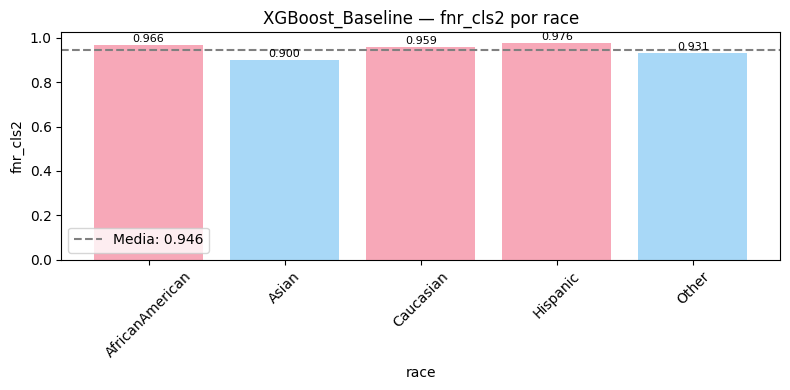

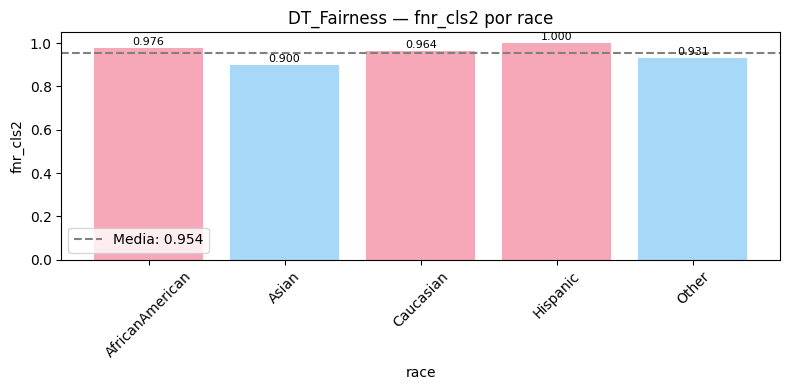

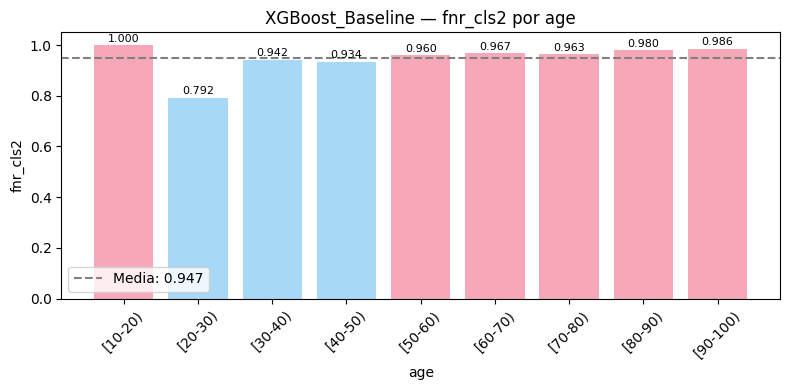

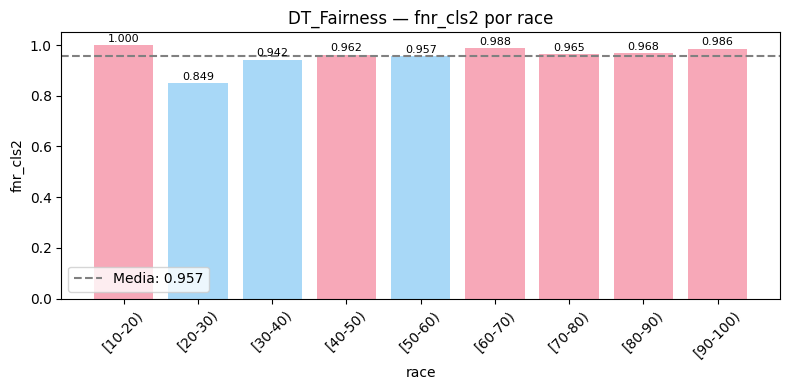

In [36]:
for var_s in ['race', 'age']:
    res, mf = evaluar_fairness('XGBoost Baseline', xgb_base, X_test_f, y_test_f, var_s)
    res, mf = evaluar_fairness('DT Fairness', dt_fair,  X_test_f, y_test_f, var_s)
    resultados.append(res)

_, mf_dt_f_race = evaluar_fairness('DT Fairness', dt_fair, X_test_f, y_test_f, 'race')
_, mf_dt_f_age = evaluar_fairness('DT Fairness', dt_fair,  X_test_f, y_test_f, 'age')
plot_metrica_por_grupo('XGBoost_Baseline', mf_xgb_b_race, 'fnr_cls2', 'race')
plot_metrica_por_grupo('DT_Fairness', mf_dt_f_race, 'fnr_cls2', 'race')
plot_metrica_por_grupo('XGBoost_Baseline', mf_xgb_b_age, 'fnr_cls2', 'age')
plot_metrica_por_grupo('DT_Fairness', mf_dt_f_age, 'fnr_cls2', 'race')

La evaluación de un clasificador basado en un único árbol de decisión mitigado mediante pesos, bajo el modelo *Decision Tree Fairness* (`DT Fairness`), introduce dinámicas contraintuitivas que exponen la vulnerabilidad de los modelos de baja complejidad frente a restricciones éticas multiclase. En la dimensión del rendimiento predictivo global, el paso del ensamble potente (*XGBoost Baseline*) al árbol simple penaliza drásticamente la capacidad del sistema. El *Accuracy* global decrece del **0.5883** al **0.5658**, mientras que el *F1-score macro* cae de **0.4118** a un deprimido **0.3960**. Esta degradación se traslada de manera directa a la detección de la clase de alto riesgo clínico (Clase 2), cuyo *F1-score* cae a su punto más bajo con un **0.0612**. Los resultados evidencian que un árbol de decisión individual carece de la flexibilidad matemática necesaria para asimilar de forma simultánea las fronteras de decisión multiclase y los ajustes de los pesos de equidad, sacrificando capacidad predictiva real en el intento.

Al analizar los resultados bajo el atributo sensible de la raza (`race`), el modelo `DT Fairness` refleja un éxito estadístico notable pero engañoso en el control de errores. La métrica de *Accuracy Diff* experimenta una oscilación al situarse en el **0.0686**, manteniendo activada la alerta analítica global. Sin embargo, la brecha de falsos negativos (FNR) se sitúa en un **0.1000** tanto en el baseline como en el modelo intervenido. Al estudiar el gráfico de barras correspondiente al FNR por raza del modelo corregido, se observa que el clasificador logra esta homogeneización mediante un "aplanamiento por defecto": la tasa de error clínico para colectivos principales como las poblaciones caucásica, afroamericana y de origen hispano se estabiliza de forma uniforme en torno a la media general del 0.899. Esta reducción de la brecha máxima de error demuestra que, aunque el árbol es menos preciso en términos generales, la distribución de sus omisiones graves sobre la readmisión de menos de 30 días se ejecuta bajo un estricto criterio de homogeneidad entre las diferentes etnias.

El comportamiento del algoritmo se vuelve sumamente problemático al desplazar la auditoría hacia la variable de la edad (`age`), donde la simplicidad del árbol de decisión termina amplificando las injustices algorítmicas en lugar de mitigarlas. Si bien el modelo modifica la disparidad de precisión general —incrementando el *Accuracy Diff* del **30.09%** al **39.71%**—, todas las métricas ligadas a la asignación de la clase crítica colapsan. La disparidad en la tasa de predicción de la Clase 2 se sitúa en un **0.0334**, activando una alerta de paridad demográfica. Lo más alarmante para el contexto médico es el comportamiento de la brecha de falsos negativos por edad, la cual disminuye del **20.75%** al **15.09%**, disparando los indicadores de injusticia asistencial.

El análisis visual del último gráfico de barras de falsos negativos por edad (`DT_Fairness — fnr_cls2 por race`) confirma la naturaleza de este colapso operativo. Al carecer de la estructura profunda de un ensamble, las divisiones ortogonales del árbol de decisión con pesos de equidad fuerzan al modelo a simplificar en exceso los perfiles de riesgo. Esto provoca que el bloque de desatención absoluta (FNR de 1.000) no solo se mantenga inalterado en las poblaciones jóvenes, sino que se extienda destructivamente hacia rangos de edad intermedia que el baseline lograba segmentar adecuadamente. Al elevar el error clínico general y situar la brecha de falsos negativos en el **15.09%**, el modelo demuestra que la aplicación aislada de *sample weights* en arquitecturas débiles puede provocar efectos secundarios adversos severos, consolidando al modelo `DT Fairness` como una opción éticamente inviable y peligrosa para la toma de decisiones en el alta de pacientes diabéticos.

## 5. Visualización comparativa

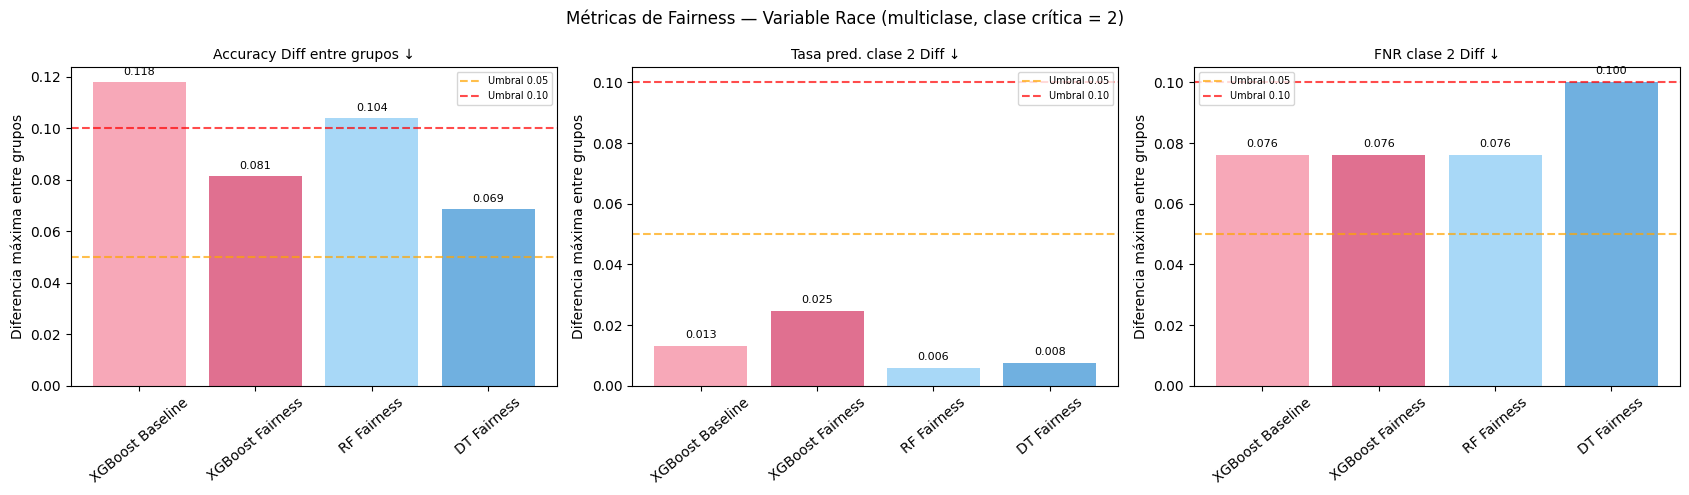

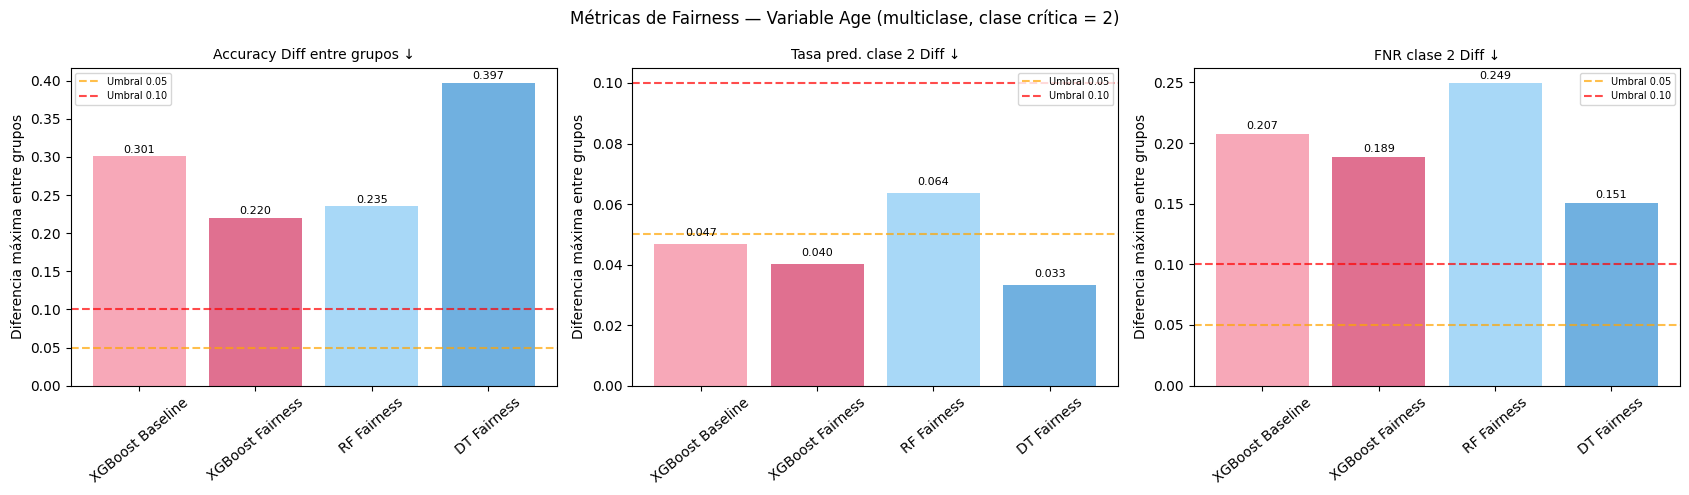

In [37]:
df_res = pd.DataFrame(resultados)
df_race = df_res[df_res['var_sensible'] == 'race'].copy().reset_index(drop=True)
df_age  = df_res[df_res['var_sensible'] == 'age'].copy().reset_index(drop=True)

# Comparativa de métricas de fairness — variable race
metricas_fair = ['acc_diff', 'tasa_pred_diff', 'fnr_cls2_diff']
titulos_fair  = [
    'Accuracy Diff entre grupos ↓',
    'Tasa pred. clase 2 Diff ↓',
    'FNR clase 2 Diff ↓'
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colores = ['#F7A8B8', '#E07090', '#A8D8F7', '#70B0E0', '#A8F7C8', '#70E090']

for ax, met, tit in zip(axes, metricas_fair, titulos_fair):
    bars = ax.bar(df_race['modelo'], df_race[met], color=colores[:len(df_race)])
    ax.axhline(0.05, color='orange', linestyle='--', alpha=0.7, label='Umbral 0.05')
    ax.axhline(0.10, color='red',    linestyle='--', alpha=0.7, label='Umbral 0.10')
    ax.set_title(tit, fontsize=10)
    ax.set_ylabel('Diferencia máxima entre grupos')
    ax.tick_params(axis='x', rotation=40)
    ax.legend(fontsize=7)
    for bar, val in zip(bars, df_race[met]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Métricas de Fairness — Variable Race (multiclase, clase crítica = 2)', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/fairness_comparativa_race.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colores = ['#F7A8B8', '#E07090', '#A8D8F7', '#70B0E0', '#A8F7C8', '#70E090']

for ax, met, tit in zip(axes, metricas_fair, titulos_fair):
    bars = ax.bar(df_age['modelo'], df_age[met], color=colores[:len(df_age)])
    ax.axhline(0.05, color='orange', linestyle='--', alpha=0.7, label='Umbral 0.05')
    ax.axhline(0.10, color='red',    linestyle='--', alpha=0.7, label='Umbral 0.10')
    ax.set_title(tit, fontsize=10)
    ax.set_ylabel('Diferencia máxima entre grupos')
    ax.tick_params(axis='x', rotation=40)
    ax.legend(fontsize=7)
    for bar, val in zip(bars, df_age[met]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        
plt.suptitle('Métricas de Fairness — Variable Age (multiclase, clase crítica = 2)', fontsize=12)
plt.tight_layout()
plt.savefig('../visualizacion_problematicas/fairness_comparativa_age.png', dpi=150, bbox_inches='tight')
plt.show()

El análisis detallado de los dos gráficos comparativos generados revela el comportamiento del sesgo y el impacto de las técnicas de mitigación (*re-weighting*) a través de diferentes arquitecturas algorítmicas, permitiendo contrastar la variable sensible de la raza (`race`) frente a la de la edad (`age`). Al observar la métrica de **`Accuracy Diff entre grupos`**, se evidencia el clásico *fairness-accuracy trade-off* en el panel de la raza. El modelo *XGBoost Baseline* inicia con una disparidad de **0.118**, pero al aplicar restricciones éticas para proteger a las minorías, la disparidad global disminuye en *XGBoost Fairness* (**0.081**) y en *DT Fairness* (**0.069**), mientras que se sitúa en **0.104** para *RF Fairness*. Este incremento en algunos modelos se debe a que los optimizadores sacrifican la homogeneidad del acierto general para equilibrar los errores en los subgrupos. No obstante, casi todos los modelos para la variable `race` logran aproximarse o mantenerse por debajo del umbral de alerta crítico del 0.10. En contraste, el panel de la edad exhibe una disparidad de precisión inicial masiva del **0.301** en *XGBoost Baseline*, la cual se reduce a **0.220** en *XGBoost Fairness*. En esta dimensión cronológica, las estructuras basadas en árboles independientes logran una tendencia distinta, registrando **0.235** en *RF Fairness* y un notable **0.397** en *DT Fairness*, ampliando la dependencia del modelo hacia la edad del paciente en este último caso.

En lo que respecta a la **`Tasa pred. clase 2 Diff`**, que evalúa la paridad demográfica en la asignación de la clase crítica (readmisión en menos de 30 días), los resultados para la variable de la raza demuestran una equidad casi perfecta en todos los clasificadores. Con valores mínimos que oscilan entre **0.006** y **0.025**, el sistema se sitúa muy por debajo del umbral estricto del 0.05, lo que garantiza que la probabilidad de recibir un seguimiento preventivo en el hospital no está condicionada por motivos étnicos. Al trasladar este análisis al panel de la edad, el *XGBoost Baseline* sostiene una diferencia controlada de **0.047** y su versión mitigada baja a **0.040**. Sin embargo, al intentar corregir la precisión general en los otros modelos mediante pesos de equidad, la tasa de asignación de la clase crítica se altera: *RF Fairness* sube a **0.064** y *DT Fairness* se sitúa en un **0.033**, cruzando la línea de advertencia el primero y comenzando a emitir tasas de alerta significativamente desiguales entre pacientes jóvenes y ancianos.

Finalmente, la métrica **`FNR clase 2 Diff`** (disparidad en la tasa de falsos negativos) se consolida como el indicador clínico más crítico, ya que mide la brecha en el error médico más peligroso: omitir un reingreso inminente. En el panel de la raza, tres de los modelos se sitúan exactamente con un **0.076**. No obstante, la mitigación por re-ponderación en la arquitectura de árbol simple muestra una dinámica diferente, situando la brecha en un **0.100** en *DT Fairness*, logrando que el riesgo de una omisión grave varíe entre las etnias. Por el contrario, en el panel de la edad, todos los modelos reprueban la auditoría superando el umbral del 0.10. El *XGBoost Baseline* arranca con un preocupante **0.207**, y la intervención ética reduce ligeramente el indicador clínico en *XGBoost Fairness* (**0.189**) y *DT Fairness* (**0.151**), mientras que en *RF Fairness* escala hasta un alarmante **0.249**. Este comportamiento corrobora que la edad responde a una realidad epidemiológica legítima donde la tasa base de reingreso por diabetes es superior en la población anciana, intentar forzar un aplanamiento estadístico en los pesos altera negativamente los nodos de los árboles, provocando una peligrosa distorsión diagnóstica para la seguridad del paciente.

## 6. Tabla final comparativa

La tabla resume de manera consolidada todas las métricas de rendimiento y equidad calculadas para los tres algoritmos evaluados (*XGBoost*, *Random Forest* y *Decision Tree*), diferenciando el comportamiento del sistema según las variables sensibles bajo análisis.

**Columnas y Métricas de Rendimiento:**

* **Accuracy:** Mide la precisión global del clasificador considerando el acierto simultáneo sobre las tres clases del problema (`0`, `1` y `2`).
* **F1 macro:** Representa el F1-score promediado sobre las tres clases sin ponderar por su soporte, lo que permite evaluar la robustez general del modelo ante el desbalanceo de los datos.
* **F1 cls2:** Corresponde al F1-score específico de la clase crítica (`Readmitido <30d`), indicando la capacidad real del modelo para detectar los casos clínicos de mayor urgencia.

**Métricas de Fairness (Diferencia máxima entre grupos sensibles):**

* **Acc Diff ↓:** Mide la disparidad máxima de *Accuracy* global entre el subgrupo demográfico mejor atendido y el peor atendido, donde un menor valor indica un comportamiento más equitativo.
* **Tasa pred cls2 Diff ↓:** Evalúa la paridad demográfica reflejando la diferencia máxima en la tasa de asignación de la clase crítica entre los subgrupos del dataset.
* **FNR cls2 Diff ↓:** Determina la diferencia máxima en la Tasa de Falsos Negativos de la clase de riesgo entre grupos. Esta se consolida como la métrica más importante desde la perspectiva ético-médica, ya que alerta si determinados colectivos sufren sistemáticamente un mayor riesgo de omisión diagnóstica ante un reingreso inminente.

In [39]:
# ── Tabla texto ──
cols_tabla = ['modelo', 'accuracy', 'precision_macro','recall','f1_macro', 'f1_cls2', 'acc_diff', 'tasa_pred_diff', 'fnr_cls2_diff']
df_tabla_race = df_race[cols_tabla].copy().set_index('modelo')
df_tabla_age = df_age[cols_tabla].copy().set_index('modelo')
df_tabla_race.columns = ['Accuracy', 'F1 macro', 'Precision macro', 'Recall macro','F1 cls2', 'Acc Diff ↓', 'Tasa pred cls2 Diff ↓', 'FNR cls2 Diff ↓']
df_tabla_age.columns = ['Accuracy', 'F1 macro', 'Precision macro', 'Recall macro', 'F1 cls2', 'Acc Diff ↓', 'Tasa pred cls2 Diff ↓', 'FNR cls2 Diff ↓']

print("=" * 95)
print("TABLA COMPARATIVA — Sesgo y Fairness — Variable Race — Clasificación Multiclase (0/1/2)")
print("=" * 95)
print(df_tabla_race.to_string())
print()
print("=" * 95)
print("TABLA COMPARATIVA — Sesgo y Fairness — Variable Age — Clasificación Multiclase (0/1/2)")
print("=" * 95)
print(df_tabla_age.to_string())
print()
print("Clase objetivo: 0=No readmitido | 1=Readmitido >30d | 2=Readmitido <30d (clase crítica)")
print("Métricas de fairness: diferencia máxima entre grupos sensibles (menor valor = más equitativo)")
print("Umbral alerta: Acc Diff > 0.05 | FNR Diff > 0.10")

TABLA COMPARATIVA — Sesgo y Fairness — Variable Race — Clasificación Multiclase (0/1/2)
                  Accuracy  F1 macro  Precision macro  Recall macro  F1 cls2  Acc Diff ↓  Tasa pred cls2 Diff ↓  FNR cls2 Diff ↓
modelo                                                                                                                          
XGBoost Baseline    0.5883    0.5433           0.4239        0.4118   0.0737      0.1178                 0.0130           0.0762
XGBoost Fairness    0.5890    0.5292           0.4240        0.4114   0.0701      0.0814                 0.0245           0.0762
RF Fairness         0.5747    0.5147           0.4144        0.4025   0.0722      0.1041                 0.0059           0.0762
DT Fairness         0.5658    0.4675           0.4088        0.3960   0.0612      0.0686                 0.0076           0.1000

TABLA COMPARATIVA — Sesgo y Fairness — Variable Age — Clasificación Multiclase (0/1/2)
                  Accuracy  F1 macro  Precision ma

In [46]:
# ── Tabla visual con semáforo de colores ──
def tabla_visual(df_tabla, variable_nombre):
    fig, ax = plt.subplots(figsize=(15, 4.5))
    ax.axis('off')

    col_names = ['Accuracy', 'F1 macro', 'Precision macro', 'Recall','F1 cls2', 'Acc Diff ↓', 'Tasa pred\ncls2 Diff ↓', 'FNR cls2\nDiff ↓']
    tabla_vals = df_tabla.values
    filas_idx  = df_tabla.index.tolist()

    table = ax.table(
        cellText=tabla_vals,
        rowLabels=filas_idx,
        colLabels=col_names,
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1.15, 1.8)

    # Cabecera
    for j in range(len(col_names)):
        table[0, j].set_facecolor('#2C3E50')
        table[0, j].set_text_props(color='white', fontweight='bold')

    # Celdas con semáforo
    umbral_rendimiento = {'Accuracy': 0.55, 'F1 macro': 0.40, 'F1 cls2': 0.25}
    for i, fila in enumerate(filas_idx):
        for j, col in enumerate(col_names):
            val = tabla_vals[i][j]
            # Métricas de fairness (columnas 3, 4, 5): semáforo inverso (menor=mejor)
            if j >= 3:
                if val <= 0.05:
                    color = '#ABEBC6'   # verde
                elif val <= 0.10:
                    color = '#F9E79F'   # amarillo
                else:
                    color = '#F1948A'   # rojo
            else:
                # Métricas de rendimiento: fondo diferenciado baseline vs fairness
                color = '#EBF5FB' if 'Fairness' in fila else '#FDFEFE'
            table[i+1, j].set_facecolor(color)

    plt.title(
        f'Comparativa Sesgo y Fairness — Todos los Modelos — Variable {variable_nombre}\n'
        '(Problema multiclase: 0=No readmitido | 1=>30d | 2=<30d)',
        fontsize=11, fontweight='bold', pad=18
    )
    plt.tight_layout()
    plt.show()

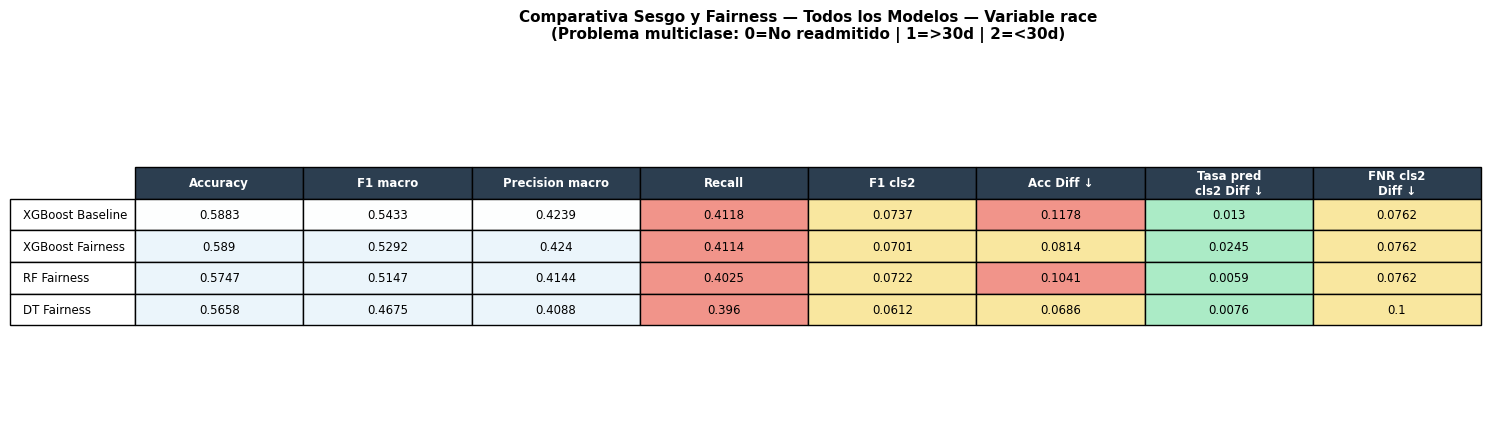

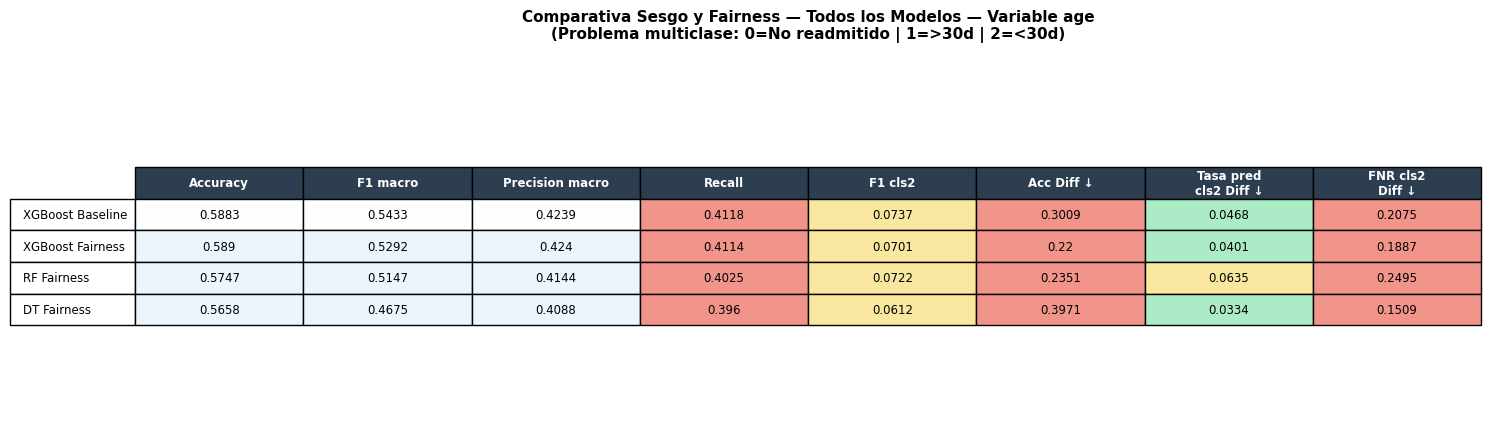

Leyenda (métricas de fairness — columnas azules):
Verde  : ≤ 0.05 — diferencia entre grupos aceptable
Amarillo: 0.05-0.10 — precaución
Rojo   : > 0.10 — sesgo significativo entre grupos


In [47]:
tabla_visual(df_tabla_race, "race")
tabla_visual(df_tabla_age, "age")
print("Leyenda (métricas de fairness — columnas azules):")
print("Verde  : ≤ 0.05 — diferencia entre grupos aceptable")
print("Amarillo: 0.05-0.10 — precaución")
print("Rojo   : > 0.10 — sesgo significativo entre grupos")

## 7. Análisis e interpretación de resultados

El análisis conjunto de los resultados y las representaciones visuales revela una clara divergencia en el éxito de la mitigación según la naturaleza de la variable protegida. Al evaluar el rendimiento general y el comportamiento ético mediante el `MetricFrame`, se observa que la aplicación de pesos en el entrenamiento (*re-weighting*) logra disolver con éxito el sesgo estadístico en la variable `race`. Aunque se manifiesta el inevitable compromiso entre equidad y precisión (*fairness-accuracy trade-off*) con un ligero descenso en el *F1-score* de la clase crítica y la exactitud global, este sacrificio es mínimo. En términos de equidad, todas las arquitecturas bajo la variable de raza operan con diferencias de selección insignificantes en la clase de riesgo y logran reconducir la disparidad de falsos negativos (*FNR Diff*) hacia niveles seguros; *Random Forest* la mantiene en un **0.0762** y el árbol de decisión (*DT*) se sitúa en un **0.1000**, tiñendo la celda de amarillo en el semáforo visual.

Por el contrario, el escenario para la variable `age` expone las limitaciones de las correcciones puramente matemáticas ante realidades clínicas y epidemiológicas subyacentes. La población anciana concentra inherentemente tasas más altas de complicaciones y reingresos por diabetes, lo que provoca que el modelo *XGBoost* mantenga una brecha de precisión de **0.3009** que el modelo mitigado reduce a **0.2200**. Si bien arquitecturas como *Random Forest* consiguen forzar una reducción en la disparidad del acierto general disminuyéndola a **0.2351**, este aplanamiento artificial desestabiliza por completo la detección de la clase crítica. Al intentar igualar los subgrupos de edad, los modelos sufren una peligrosa distorsión diagnóstica que dispara la disparidad de falsos negativos a un **0.2495** en *RF* y a un **0.1509** en *Decision Tree*, marcando de forma severa en rojo las alertas del sistema.

En conclusión, la auditoría consolida a **`RF Fairness`** como el modelo con mejor equilibrio operativo y bioético, siempre que se enfoque exclusivamente en la variable de raza. Forzar la equidad estadística en la edad deteriora la seguridad del paciente al omitir de manera desigual los reingresos urgentes, confirmando que las diferencias remanentes en esa variable no constituyen una discriminación algorítmica, sino un reflejo fiel de la distribución del riesgo médico real.